In [1]:
import os
import random
import shutil
from pathlib import Path

import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
import torch.nn as nn
from rasterio.windows import Window
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from tqdm import tqdm

import albumentations as A
import gradio as gr
import segmentation_models_pytorch as smp
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

DATASET_PATH = Path("/content")
IMAGES_DIR = DATASET_PATH / "AerialImageDataset" / "train" / "images"
MASKS_DIR = DATASET_PATH / "AerialImageDataset" / "train" / "gt"

MODEL_WEIGHTS_PATH = Path("linknet_resnet34_buildings.pth")

MODEL_NAME = "yolo11n-obb.pt"
REAL_CAR_LEN_M = 4.5
DEFAULT_SCALE_M_PER_PIXEL = 0.3

CROP_SIZE = 1024
TILE_SIZE = 512
STRIDE = 400
BATCH_SIZE = 8
NUM_EPOCHS = 5
LR = 1e-4

Device: cuda


## 2. Загрузка датасета

Если датасет уже скачан и лежит в `DATASET_PATH`, эту ячейку можно не запускать.

In [2]:
def download_inria_dataset(target_dir: Path = DATASET_PATH) -> Path:
    source_path = Path(kagglehub.dataset_download("sagar100rathod/inria-aerial-image-labeling-dataset"))
    target_dir.mkdir(parents=True, exist_ok=True)
    shutil.copytree(source_path, target_dir, dirs_exist_ok=True)
    print(f"Dataset copied to: {target_dir}")
    return target_dir

# download_inria_dataset()

In [3]:
def normalize_rgb(img: np.ndarray) -> np.ndarray:
    """Приводит RGB-изображение к uint8 для визуализации/YOLO."""
    img = np.asarray(img)
    if img.max() > 255:
        img = (img / (img.max() / 255)).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    return img


def get_tile_coords(width: int, height: int, tile_size: int, stride: int) -> list[tuple[int, int]]:
    """Координаты тайлов с обязательным покрытием правого и нижнего края."""
    if width < tile_size or height < tile_size:
        raise ValueError("Изображение меньше размера тайла. Уменьшите TILE_SIZE.")

    xs = list(range(0, width - tile_size + 1, stride))
    ys = list(range(0, height - tile_size + 1, stride))

    if xs[-1] != width - tile_size:
        xs.append(width - tile_size)
    if ys[-1] != height - tile_size:
        ys.append(height - tile_size)

    return [(x, y) for y in ys for x in xs]


def read_rgb_window(src: rasterio.io.DatasetReader, window: Window | None = None) -> np.ndarray:
    img = src.read([1, 2, 3], window=window)
    return np.transpose(img, (1, 2, 0))

## 4. Оценка масштаба изображения

Масштаб оценивается по длине автомобилей, найденных YOLO. Если автомобили не найдены, используется `DEFAULT_SCALE_M_PER_PIXEL`. Для точных расчетов площади лучше брать масштаб из метаданных снимка, если он доступен.

In [4]:
def process_aerial_scale(
    tif_path: str | Path,
    model_name: str = MODEL_NAME,
    crop_size: int = CROP_SIZE,
    real_car_len_m: float = REAL_CAR_LEN_M,
    default_scale: float = DEFAULT_SCALE_M_PER_PIXEL,
) -> float:
    model_yolo = YOLO(model_name)

    with rasterio.open(tif_path) as src:
        cx, cy = src.width // 2, src.height // 2
        left = max(0, cx - crop_size // 2)
        top = max(0, cy - crop_size // 2)
        width = min(crop_size, src.width - left)
        height = min(crop_size, src.height - top)
        window = Window(left, top, width, height)
        img = normalize_rgb(read_rgb_window(src, window))

    results = model_yolo.predict(img, conf=0.3, imgsz=crop_size, device=DEVICE, verbose=False)
    obb = getattr(results[0], "obb", None)

    if obb is None or obb.xywhr is None or len(obb.xywhr) == 0:
        print(f"Машины не найдены. Используется масштаб по умолчанию: {default_scale} м/пиксель")
        return default_scale

    wh = obb.xywhr[:, 2:4].cpu().numpy()
    pixel_lengths = np.max(wh, axis=1)
    pixel_lengths = pixel_lengths[(pixel_lengths > 10) & (pixel_lengths < 150)]

    if len(pixel_lengths) == 0:
        print(f"Подходящие машины не найдены. Используется масштаб по умолчанию: {default_scale} м/пиксель")
        return default_scale

    avg_px_len = float(np.mean(pixel_lengths))
    scale = real_car_len_m / avg_px_len
    print(f"Расчетный масштаб: {scale:.4f} м/пиксель")
    return scale

## 5. Dataset и DataLoader

In [5]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])


class InriaSlidingWindowDataset(Dataset):
    def __init__(
        self,
        img_path: str | Path,
        mask_path: str | Path | None = None,
        tile_size: int = TILE_SIZE,
        stride: int = STRIDE,
        transform: A.Compose | None = None,
    ):
        self.img_path = Path(img_path)
        self.mask_path = Path(mask_path) if mask_path is not None else None
        self.tile_size = tile_size
        self.transform = transform

        with rasterio.open(self.img_path) as src:
            self.height, self.width = src.height, src.width

        self.coords = get_tile_coords(self.width, self.height, tile_size, stride)

    def __len__(self) -> int:
        return len(self.coords)

    def __getitem__(self, idx: int):
        x, y = self.coords[idx]
        window = Window(x, y, self.tile_size, self.tile_size)

        with rasterio.open(self.img_path) as src:
            img = read_rgb_window(src, window)

        if self.mask_path is not None:
            with rasterio.open(self.mask_path) as mask_src:
                mask = mask_src.read(1, window=window)
            mask = (mask > 0).astype(np.float32)
        else:
            mask = np.zeros((self.tile_size, self.tile_size), dtype=np.float32)

        if self.transform is not None:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        return img, mask


def setup_data(
    img_dir: str | Path = IMAGES_DIR,
    mask_dir: str | Path = MASKS_DIR,
    split_ratio: float = 0.8,
    batch_size: int = BATCH_SIZE,
):
    img_dir = Path(img_dir)
    mask_dir = Path(mask_dir)

    all_files = sorted([f.name for f in img_dir.glob("*.tif")])
    random.Random(SEED).shuffle(all_files)

    split_idx = int(len(all_files) * split_ratio)
    train_files = all_files[:split_idx]
    val_files = all_files[split_idx:]

    train_datasets = [
        InriaSlidingWindowDataset(img_dir / name, mask_dir / name, transform=train_transform)
        for name in train_files
    ]
    val_datasets = [
        InriaSlidingWindowDataset(img_dir / name, mask_dir / name, transform=None)
        for name in val_files
    ]

    train_loader = DataLoader(
        ConcatDataset(train_datasets),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )
    val_loader = DataLoader(
        ConcatDataset(val_datasets),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    return train_loader, val_loader, train_files, val_files

## 6. Модель, loss и метрики

In [6]:
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()
        self.dice = smp.losses.DiceLoss(mode="binary")

    def forward(self, preds, targets):
        return 0.5 * self.bce(preds, targets) + 0.5 * self.dice(preds, targets)


def build_model() -> nn.Module:
    return smp.Linknet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        classes=1,
        activation="sigmoid",
    )


def segmentation_metrics(preds, targets, threshold: float = 0.5, eps: float = 1e-7) -> dict[str, float]:
    preds = (preds > threshold).float()
    targets = (targets > 0.5).float()

    tp = (preds * targets).sum()
    fp = (preds * (1 - targets)).sum()
    fn = ((1 - preds) * targets).sum()

    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)

    return {
        "iou": float(iou.item()),
        "dice": float(dice.item()),
        "precision": float(precision.item()),
        "recall": float(recall.item()),
    }

## 7. Обучение и валидация

In [7]:
def validate(model, loader, criterion, device: str = DEVICE) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    metric_sums = {"iou": 0.0, "dice": 0.0, "precision": 0.0, "recall": 0.0}
    n_batches = 0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)

            total_loss += loss.item()
            metrics = segmentation_metrics(outputs, masks)
            for key in metric_sums:
                metric_sums[key] += metrics[key]
            n_batches += 1

    result = {key: value / max(n_batches, 1) for key, value in metric_sums.items()}
    result["loss"] = total_loss / max(n_batches, 1)
    return result


def train(model, train_loader, val_loader, optimizer, criterion, epochs: int = NUM_EPOCHS, device: str = DEVICE):
    model.to(device)
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}")
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss = total_loss / max(len(train_loader), 1)
        val_metrics = validate(model, val_loader, criterion, device)

        epoch_info = {"epoch": epoch + 1, "train_loss": train_loss, **val_metrics}
        history.append(epoch_info)

        print(
            f"Epoch {epoch + 1}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={val_metrics['loss']:.4f}, "
            f"IoU={val_metrics['iou']:.4f}, "
            f"Dice={val_metrics['dice']:.4f}"
        )

    return history

## 8. Запуск обучения

In [ ]:
train_loader, val_loader, train_filenames, val_filenames = setup_data()

model = build_model().to(DEVICE)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = train(model, train_loader, val_loader, optimizer, criterion, epochs=NUM_EPOCHS)
torch.save(model.state_dict(), MODEL_WEIGHTS_PATH)
print(f"Weights saved to: {MODEL_WEIGHTS_PATH}")

## 9. Инференс на полном изображении

In [8]:
def predict_and_stitch(
    model: nn.Module,
    tif_path: str | Path,
    scale_m_per_pixel: float,
    tile_size: int = TILE_SIZE,
    stride: int = STRIDE,
    batch_size: int = BATCH_SIZE,
    device: str = DEVICE,
):
    model.eval()

    with rasterio.open(tif_path) as src:
        height, width = src.height, src.width

    full_mask = np.zeros((height, width), dtype=np.float32)
    count_map = np.zeros((height, width), dtype=np.float32)

    dataset = InriaSlidingWindowDataset(tif_path, tile_size=tile_size, stride=stride)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    idx = 0
    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Inference"):
            images = images.to(device)
            preds = model(images).cpu().numpy()

            for i in range(preds.shape[0]):
                x, y = dataset.coords[idx]
                full_mask[y:y + tile_size, x:x + tile_size] += preds[i, 0]
                count_map[y:y + tile_size, x:x + tile_size] += 1.0
                idx += 1

    final_mask = (full_mask / np.maximum(count_map, 1) > 0.5).astype(np.uint8)
    area_m2 = float(final_mask.sum() * (scale_m_per_pixel ** 2))
    return final_mask, area_m2


def visualize_result(tif_path: str | Path, pred_mask: np.ndarray):
    with rasterio.open(tif_path) as src:
        img = normalize_rgb(read_rgb_window(src))

    overlay = np.zeros_like(img)
    overlay[pred_mask == 1] = [255, 0, 0]
    blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    fig = plt.figure(figsize=(12, 12))
    plt.imshow(blended)
    plt.title("Результат сегментации зданий")
    plt.axis("off")
    plt.tight_layout()
    return fig

## 10. Проверка на размеченной маске

Зеленый — верное предсказание здания, красный — ложное срабатывание, синий — пропущенное здание.

In [9]:
def compare_with_gt(
    tif_path: str | Path,
    pred_mask: np.ndarray,
    scale_m_per_pixel: float,
    num_crops: int = 3,
    crop_size: int = 1024,
):
    tif_path = Path(tif_path)
    gt_path = Path(str(tif_path).replace("/images/", "/gt/"))

    with rasterio.open(tif_path) as src:
        original_img = normalize_rgb(read_rgb_window(src))
        height, width = src.height, src.width

    with rasterio.open(gt_path) as src:
        gt_mask = (src.read(1) > 0).astype(np.uint8)

    pred_binary = (pred_mask > 0).astype(np.uint8)
    intersection = np.logical_and(pred_binary, gt_mask).sum()
    union = np.logical_or(pred_binary, gt_mask).sum()

    iou = intersection / max(union, 1)
    dice = 2 * intersection / max(pred_binary.sum() + gt_mask.sum(), 1)

    area_gt = float(gt_mask.sum() * (scale_m_per_pixel ** 2))
    area_pred = float(pred_binary.sum() * (scale_m_per_pixel ** 2))
    area_error = area_pred - area_gt
    relative_area_error = area_error / max(area_gt, 1) * 100

    print(f"Файл: {tif_path.name}")
    print(f"IoU: {iou:.4f}")
    print(f"Dice: {dice:.4f}")
    print(f"Площадь GT: {area_gt:,.1f} м²")
    print(f"Площадь Pred: {area_pred:,.1f} м²")
    print(f"Ошибка площади: {area_error:+,.1f} м² ({relative_area_error:+.2f}%)")

    overlay = np.zeros_like(original_img)
    overlay[(pred_binary == 1) & (gt_mask == 1)] = [0, 255, 0]
    overlay[(pred_binary == 1) & (gt_mask == 0)] = [255, 0, 0]
    overlay[(pred_binary == 0) & (gt_mask == 1)] = [0, 0, 255]
    blended = cv2.addWeighted(original_img, 0.7, overlay, 0.3, 0)

    fig, axes = plt.subplots(num_crops, 1, figsize=(10, num_crops * 8))
    if num_crops == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        y = random.randint(0, max(height - crop_size, 0))
        x = random.randint(0, max(width - crop_size, 0))
        crop = blended[y:y + crop_size, x:x + crop_size]
        ax.imshow(crop)
        ax.set_title(f"Кроп {i + 1}: зеленый=TP, красный=FP, синий=FN")
        ax.axis("off")

    plt.tight_layout()
    return fig

## 11. Пример инференса

Расчетный масштаб: 0.2839 м/пиксель


Inference: 100%|██████████| 22/22 [00:11<00:00,  1.90it/s]


Площадь застройки: 154,051.96 м²


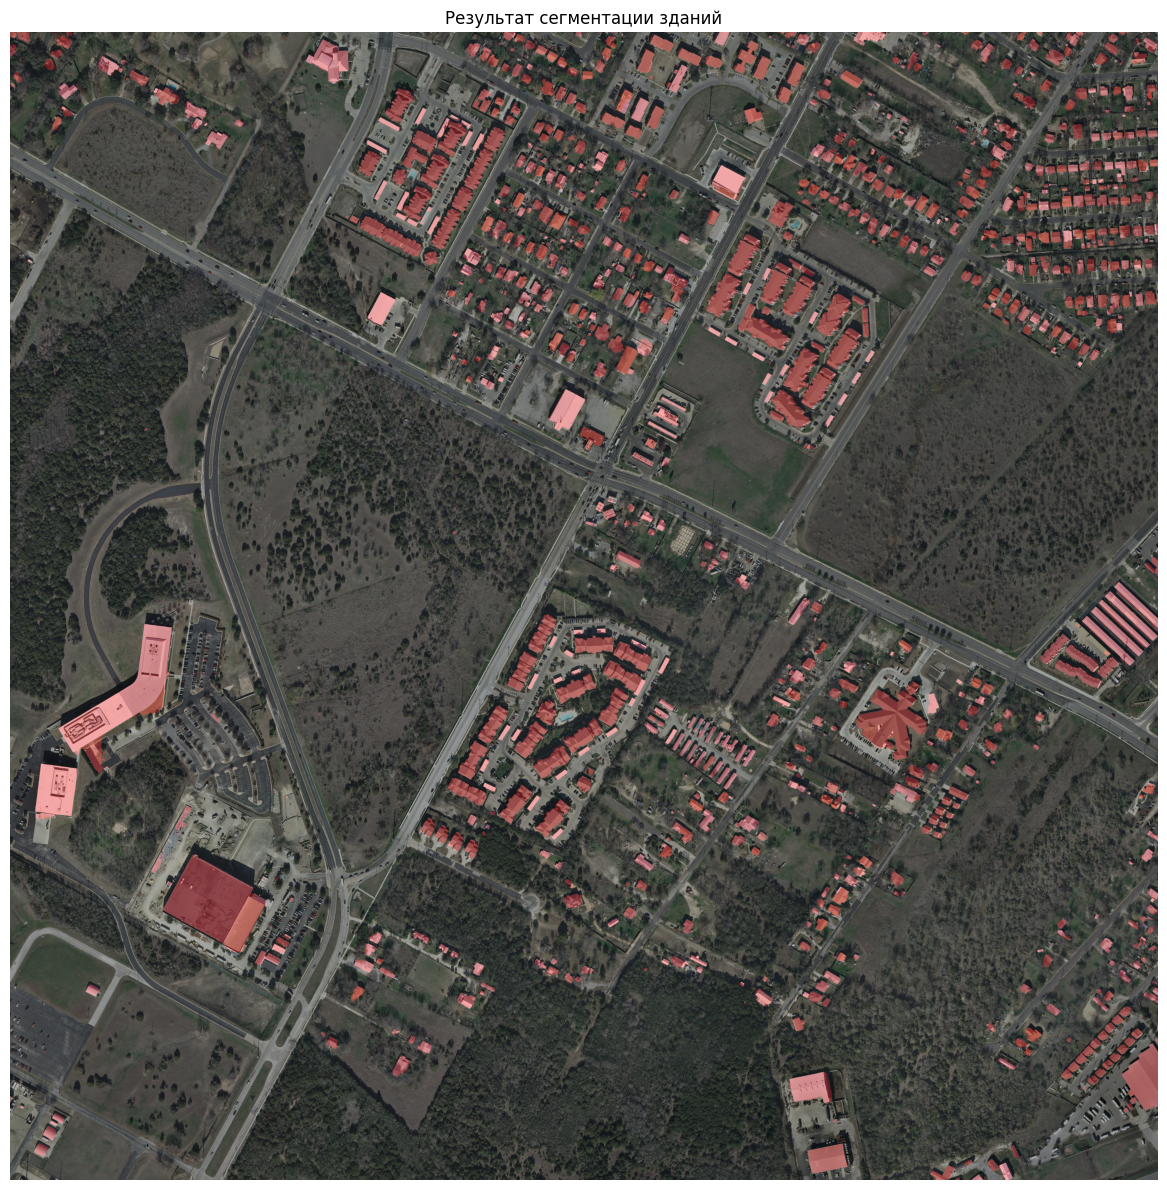

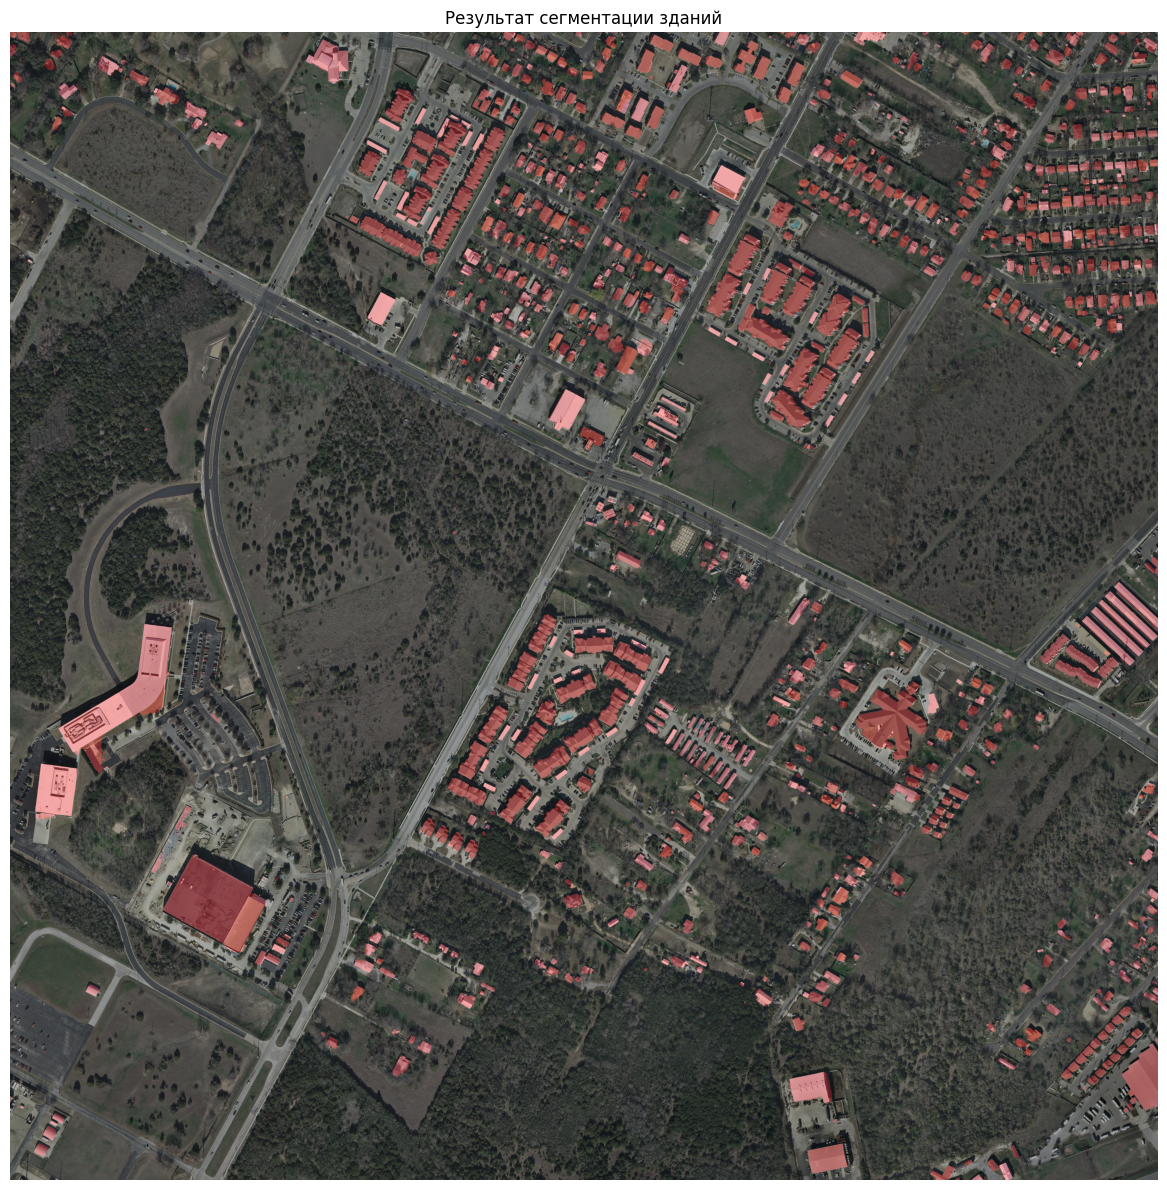

In [10]:
tif_file = "austin31.tif"

model = build_model().to(DEVICE)
model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=DEVICE))
model.eval()

scale = process_aerial_scale(tif_file)
pred_mask, area_m2 = predict_and_stitch(model, tif_file, scale)
print(f"Площадь застройки: {area_m2:,.2f} м²")

visualize_result(tif_file, pred_mask)

## 12. Gradio-интерфейс

In [ ]:
def process_image(img_path):
    try:
        scale = process_aerial_scale(img_path)
        mask, area = predict_and_stitch(model, img_path, scale)
        fig = visualize_result(img_path, mask)

        report = (
            "### Отчет анализа\n"
            f"- **Масштаб:** `{scale:.4f}` м/пиксель\n"
            f"- **Площадь застройки:** `{area:,.2f}` м²"
        )
        return fig, report
    except Exception as exc:
        return None, f"Ошибка: {exc}"


with gr.Blocks() as demo:
    gr.Markdown("# Анализ спутниковых снимков")

    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="filepath", label="Загрузите TIF")
            btn = gr.Button("Запустить", variant="primary")
        with gr.Column():
            plot_out = gr.Plot(label="Карта сегментации")
            text_out = gr.Markdown("Результаты появятся здесь")

    btn.click(process_image, inputs=input_img, outputs=[plot_out, text_out])

demo.launch(theme=gr.themes.Soft())

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Расчетный масштаб: 0.2958 м/пиксель


Inference: 100%|██████████| 22/22 [00:10<00:00,  2.14it/s]


## Комментарий по результатам

Из-за ограничений видеопамяти используется LinkNet с `resnet34`, а не более тяжелая U-Net. Качество стоит подтверждать не только визуально и не только ошибкой площади, а метриками сегментации: IoU, Dice, Precision и Recall. Проблемы ожидаемы на монохромных объектах, парковках, лесах и зданиях необычной формы. Для улучшения можно увеличить число эпох, расширить аугментации и использовать более сильный encoder при наличии GPU-памяти.